### Melbourne Housing price Analysis
### Predicting house prices using the Melbourne Housing Market dataset

---

## Introduction

This notebook performs an regression analysis on the Melbourne Housing Market dataset.
The dataset itself can be found here: [Melbourne Housing Market dataset](https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market) <br> The goal is to build a linear regression model that estimates house prices
based on property characteristics.

**The project follows these steps:**

1. Setup & Imports
2. Load & Explore the Raw Data
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Train / Test Split
6. Handling Missing Data & Outliers
7. Feature Selection & Engineering
8. Regression Modelling (OLS)
9. Model Evaluation
10. Interpretation & Conclusions

## Dataset Overview

The data was scraped from publicly available auction results on 
[Domain.com.au](https://www.domain.com.au/) and covers residential 
property sales across Melbourne, Australia.

### Column Descriptions

| Column | Description |
|---|---|
| `Suburb` | Suburb name |
| `Address` | Property address |
| `Rooms` | Number of rooms |
| `Price` | Sale price in Australian dollars *(target variable)* |
| `Type` | `h` = house/cottage/villa/terrace, `u` = unit/duplex, `t` = townhouse |
| `Method` | `S` = sold, `SP` = sold prior, `PI` = passed in, `VB` = vendor bid, `SA` = sold after auction *(and others)* |
| `SellerG` | Real estate agent |
| `Date` | Date of sale |
| `Distance` | Distance from Melbourne CBD (km) |
| `Regionname` | General region (North, South, West, etc.) |
| `Propertycount` | Number of properties in the suburb |
| `Bedroom2` | Number of bedrooms (scraped from a secondary source) |
| `Bathroom` | Number of bathrooms |
| `Car` | Number of car spots |
| `Landsize` | Land size in m² |
| `BuildingArea` | Building size in m² |
| `YearBuilt` | Year the property was built |
| `CouncilArea` | Governing council for the suburb |
| `Lattitude` | Latitude coordinate |
| `Longtitude` | Longitude coordinate |

## 1. Setup & Imports

Importing all needed libraries for the analysis and a fixed random seed is set to ensure reproducibility

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Plot styling
sns.set_theme(style="whitegrid")

# Reproducibility
SEED = 42

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load & Explore the Raw data

Loading the dataset and perform initial eda to understand structure, size, data types, what's missing before doing any cleaning

In [2]:
df = pd.read_csv('Melbourne_housing_FULL.csv')

In [3]:
df.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
11756,West Footscray,8 View St,3,h,1074000.0,S,Village,3/12/2016,8.2,3012.0,...,2.0,2.0,355.0,NaN,1950.0,Maribyrnong City Council,-37.79140,144.87420,Western Metropolitan,5058.0
21333,Malvern,2/102 Stanhope St,2,u,1000000.0,S,Jellis,16/09/2017,5.9,3144.0,...,1.0,1.0,NaN,NaN,1970.0,Stonnington City Council,-37.85919,145.03683,Southern Metropolitan,4675.0
25491,Albion,46 Derrimut St,2,h,740000.0,PI,Barry,28/10/2017,10.5,3020.0,...,1.0,3.0,NaN,NaN,NaN,Brimbank City Council,-37.77960,144.81718,Western Metropolitan,2185.0
29972,Werribee,4 Mekong Cl,3,h,420000.0,S,Barry,6/01/2018,14.7,3030.0,...,2.0,2.0,341.0,106.0,1995.0,Wyndham City Council,-37.88098,144.65754,Western Metropolitan,16166.0
11976,Cremorne,7/18 Kelso St,2,u,546000.0,S,Biggin,8/10/2016,2.5,3121.0,...,1.0,1.0,0.0,NaN,1980.0,Yarra City Council,-37.82820,144.98970,Northern Metropolitan,1123.0


In [4]:
print(f"Number of Row : {df.shape[0]}\nNumber of Columns : {df.shape[1]}")

Number of Row : 34857
Number of Columns : 21


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  str    
 1   Address        34857 non-null  str    
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  str    
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  str    
 6   SellerG        34857 non-null  str    
 7   Date           34857 non-null  str    
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  str    
 17  Lattitude      26881 non-null  float64
 18  Longtitude     26

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing as % of total rows:")
print((df.isnull().sum() / len(df) * 100).round(1))

Missing values per column:
Suburb               0
Address              0
Rooms                0
Type                 0
Price             7610
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
YearBuilt        19306
CouncilArea          3
Lattitude         7976
Longtitude        7976
Regionname           3
Propertycount        3
dtype: int64

Missing as % of total rows:
Suburb            0.0
Address           0.0
Rooms             0.0
Type              0.0
Price            21.8
Method            0.0
SellerG           0.0
Date              0.0
Distance          0.0
Postcode          0.0
Bedroom2         23.6
Bathroom         23.6
Car              25.0
Landsize         33.9
BuildingArea     60.6
YearBuilt        55.4
CouncilArea       0.0
Lattitude        22.9
Longtitude       22.9
Regionname        0.0
Property

In [7]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.000000,2.724700e+04,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,13742.00000,15551.000000,26881.000000,26881.000000,34854.000000
mean,3.031012,1.050173e+06,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,160.25640,1965.289885,-37.810634,145.001851,7572.888306
std,0.969933,6.414671e+05,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,401.26706,37.328178,0.090279,0.120169,4428.090313
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1196.000000,-38.190430,144.423790,83.000000
25%,2.000000,6.350000e+05,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,102.00000,1940.000000,-37.862950,144.933500,4385.000000
50%,3.000000,8.700000e+05,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,136.00000,1970.000000,-37.807600,145.007800,6763.000000
75%,4.000000,1.295000e+06,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,188.00000,2000.000000,-37.754100,145.071900,10412.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,44515.00000,2106.000000,-37.390200,145.526350,21650.000000


### Initial Observations

**Missing Data:**
- `Price` (21.8% missing) — rows are unusable and will be dropped.
- `BuildingArea` (60.6%) and `YearBuilt` (55.4%) have majority missing values.
- `Bedroom2`, `Bathroom`, `Car` (~23–25%) — moderate missing values.

**Suspicious Values:**
- `Landsize` max = 433,014 m² and `BuildingArea` max = 44,515 m² suggest 
 outliers.
- `YearBuilt` min = 1196 probably data entry error.
- `Bedroom2` max = 30 and `Car` max = 26 probably some extra luxurious place.

**Skew:**
- `Price` mean (~$1.05M) is higher than the median (~$870k), .

## 3. Data Cleaning

Based on the initial exploration, we address the following issues:
- Drop rows where `Price` is missing (our target variable — unusable without it)
- Drop columns that are irrelevant, redundant, or have too much missing data to be useful
- Fix clearly erroneous values (e.g. `YearBuilt` = 1196)
- Reset the index after dropping rows

In [8]:
# Drop rows where Price is missing
df = df.dropna(subset=['Price'])
print(f"Rows after dropping missing Price: {df.shape[0]}")

Rows after dropping missing Price: 27247


In [9]:
# Drop columns that are irrelevant or redundant
cols_to_drop = [
    'Address',       # too granular, not useful for modelling
    'SellerG',       # agent name, not a property characteristic
    'Postcode',      # redundant with Suburb and Regionname
    'Lattitude',     # replaced by Distance and Regionname
    'Longtitude',    # same
    'Bedroom2',      # redundant with Rooms, and more missing data
]
df = df.drop(columns=cols_to_drop)
print(f"Columns remaining: {df.shape[1]}")
print(df.columns.tolist())

Columns remaining: 15
['Suburb', 'Rooms', 'Type', 'Price', 'Method', 'Date', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Regionname', 'Propertycount']


In [10]:
# Fix YearBuilt values
print(f"\nYearBuilt below 1800: {(df['YearBuilt'] < 1800).sum()} rows")
df = df[~(df['YearBuilt'] < 1800) | df['YearBuilt'].isna()]


YearBuilt below 1800: 1 rows


In [11]:
# Reset index
df = df.reset_index(drop=True)
print(f"\nFinal shape after cleaning: {df.shape}")


Final shape after cleaning: (27246, 15)


### Cleaning Summary

| Action | Detail |
|---|---|
| Dropped rows | 7,610 rows where `Price` was missing |
| Dropped columns | `Address`, `SellerG`, `Postcode`, `Lattitude`, `Longtitude`, `Bedroom2` |
| Fixed values | 1 row with `YearBuilt` = 1196 removed |
| Remaining data | 27,246 rows × 15 columns |

**Columns kept for further analysis:**
`Suburb`, `Rooms`, `Type`, `Price`, `Method`, `Date`, `Distance`, 
`Bathroom`, `Car`, `Landsize`, `BuildingArea`, `YearBuilt`, 
`CouncilArea`, `Regionname`, `Propertycount`

Missing data in the remaining columns (`Bathroom`, `Car`, `Landsize`, 
`BuildingArea`, `YearBuilt`) will be handled **after** the train/test 
split to prevent data leakage.

## 4. Exploratory Data Analysis

Before modelling, we visually explore the data to understand distributions, 
relationships, and patterns. Key tasks are:
- Understand the distribution of `Price` and confirm the need for a log transformation
- Explore distributions of key numeric variables
- Examine relationships between predictors and `Price`
- Explore categorical variables (`Type`, `Regionname`)

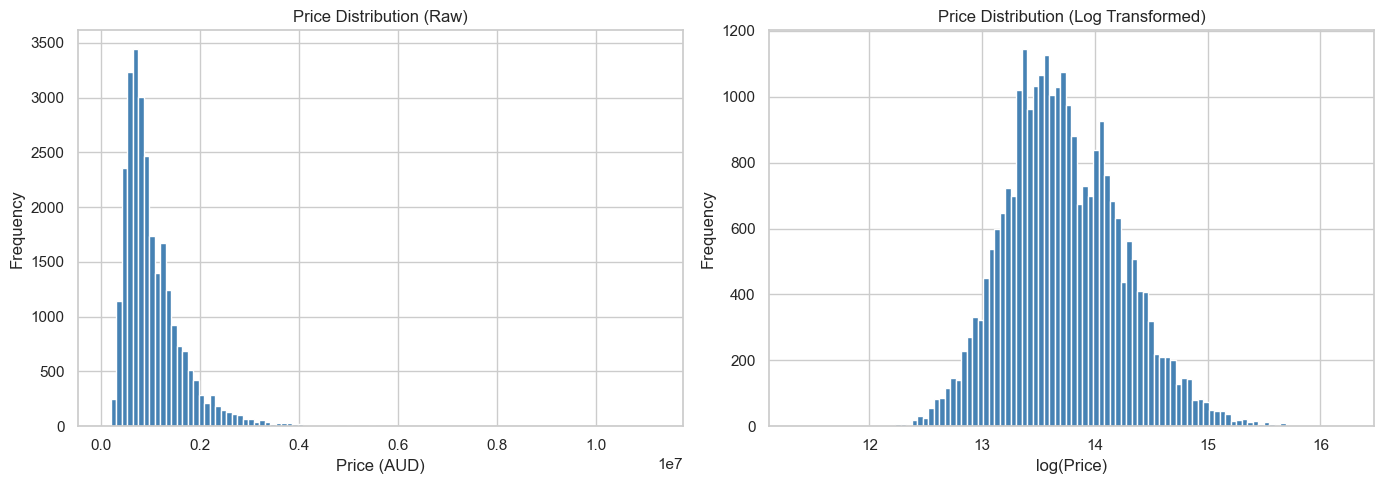

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Price
axes[0].hist(df['Price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price (AUD)')
axes[0].set_ylabel('Frequency')

# Log Price
axes[1].hist(np.log(df['Price']), bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Price Distribution (Log Transformed)')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Observation
The raw `Price` distribution is heavily **right-skewed** — most properties 
cluster at lower prices with a long tail of high-value outliers. This violates 
the normality assumption of linear regression.

After applying `log(Price)`, the distribution becomes approximately 
**normal (bell-shaped)**, centred around 13–14 (corresponding to ~$440k–$1.2M). 
We will use `log(Price)` as our target variable in the regression model.

### 4.2 Numeric Variable Distributions

We plot the distributions of key numeric variables to identify skew, 
outliers, and anomalies that may need to be addressed before modelling.

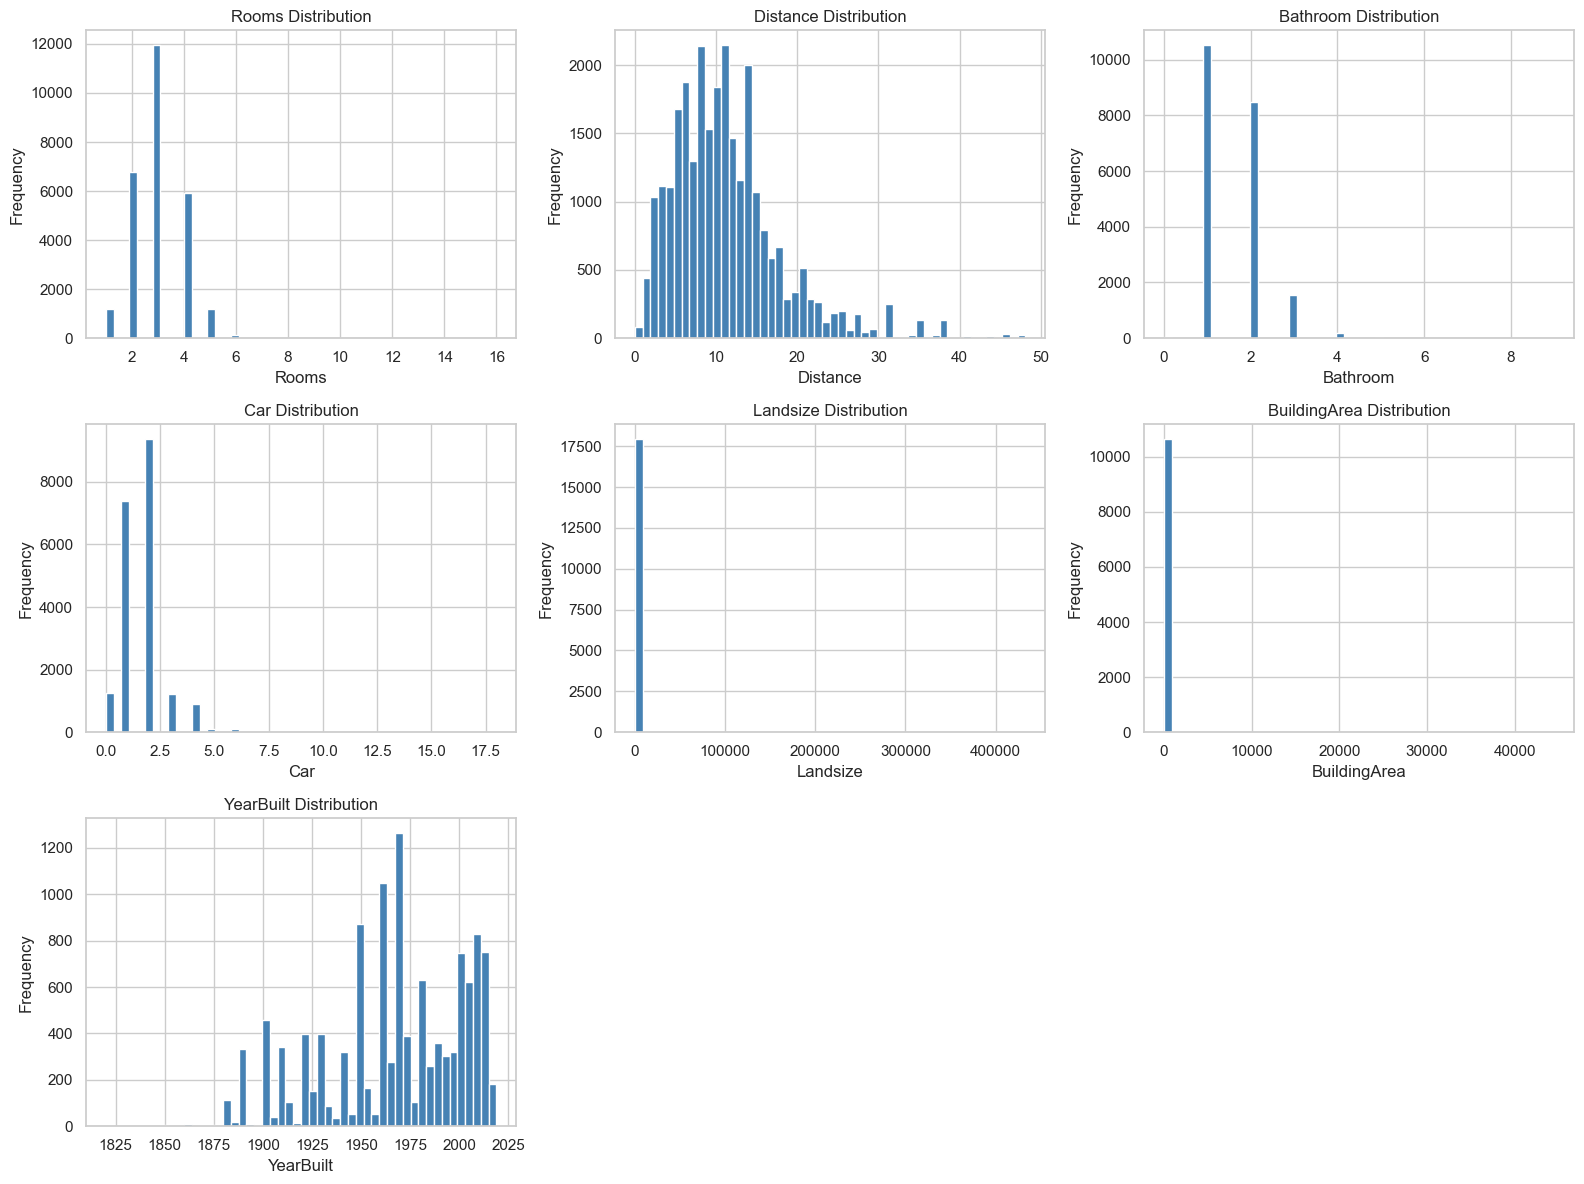

In [13]:
numeric_cols = ['Rooms', 'Distance', 'Bathroom', 'Car', 
                'Landsize', 'BuildingArea', 'YearBuilt']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide the 2 unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4.3 Landsize & BuildingArea (Log Scale)

`Landsize` and `BuildingArea` contain extreme outliers that compress the 
distribution when plotted on a linear scale. We use a log scale to visualise 
their true shape without removing any data at this stage.

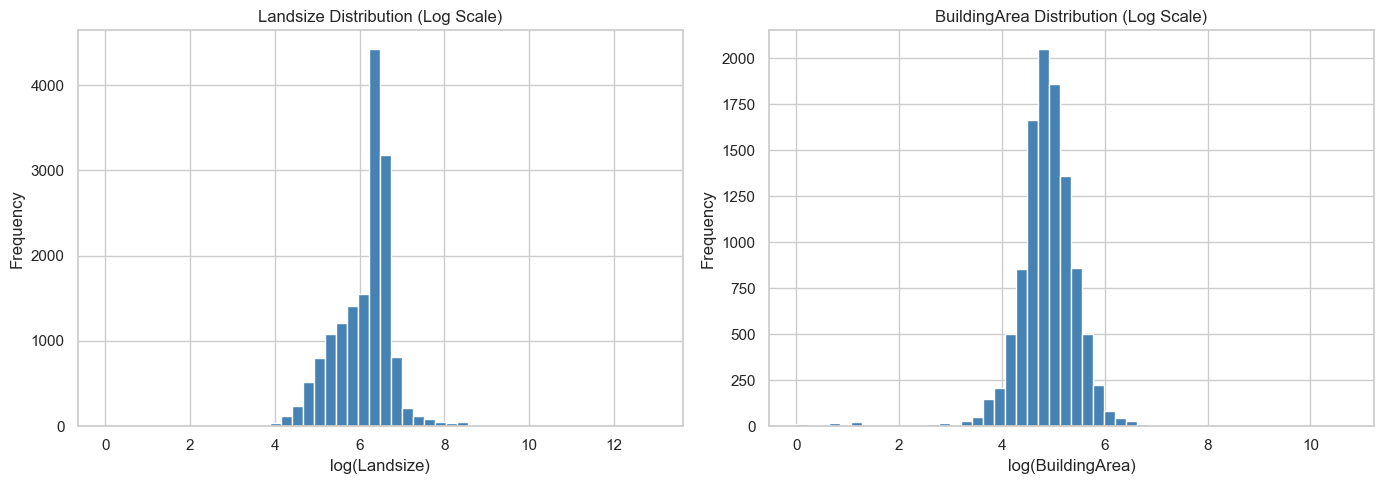

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Landsize', 'BuildingArea']):
    data = df[col].dropna()
    data = data[data > 0]  # log(0) is undefined
    ax.hist(np.log(data), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} Distribution (Log Scale)')
    ax.set_xlabel(f'log({col})')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 4.4 Correlations with Price

We examine how numeric variables relate to `log(Price)` using a 
correlation heatmap and scatter plots. We use `log(Price)` here since 
that is the transformation we will use in the model.

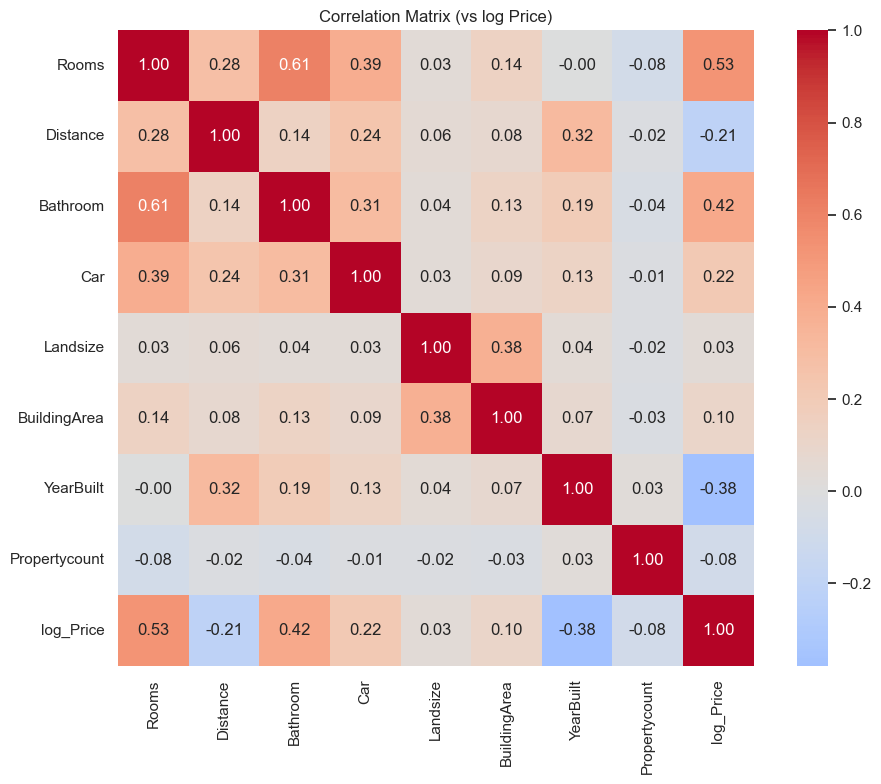

In [15]:
# Create a temporary dataframe with log(Price) for EDA purposes
df_eda = df[['Rooms', 'Distance', 'Bathroom', 'Car', 
             'Landsize', 'BuildingArea', 'YearBuilt', 
             'Propertycount']].copy()
df_eda['log_Price'] = np.log(df['Price'])

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_eda.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Correlation Matrix (vs log Price)')
plt.tight_layout()
plt.show()

### Observation
`Rooms` and `Bathroom` show moderate correlation (r = 0.61), 
meaning they partially measure the same thing — property size. 
Coefficients for these variables should be interpreted with caution.
`Distance` shows a negative correlation with `log(Price)` (-0.21), 
confirming that proximity to CBD is associated with higher prices.
`YearBuilt` negative correlation (-0.38) likely reflects that older 
properties tend to be in more expensive inner-city suburbs.

### 4.5 Price by Categorical Variables

We examine how `log(Price)` varies across property types and regions 
using boxplots. This helps us understand whether these categorical 
variables have meaningful predictive power worth including in the model.

C:\Users\m.savickasa\AppData\Local\Temp\ipykernel_40824\1434088798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y=np.log(df['Price']),
C:\Users\m.savickasa\AppData\Local\Temp\ipykernel_40824\1434088798.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['House/Villa/Terrace (h)',
C:\Users\m.savickasa\AppData\Local\Temp\ipykernel_40824\1434088798.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Regionname', y=np.log(df['Price']),


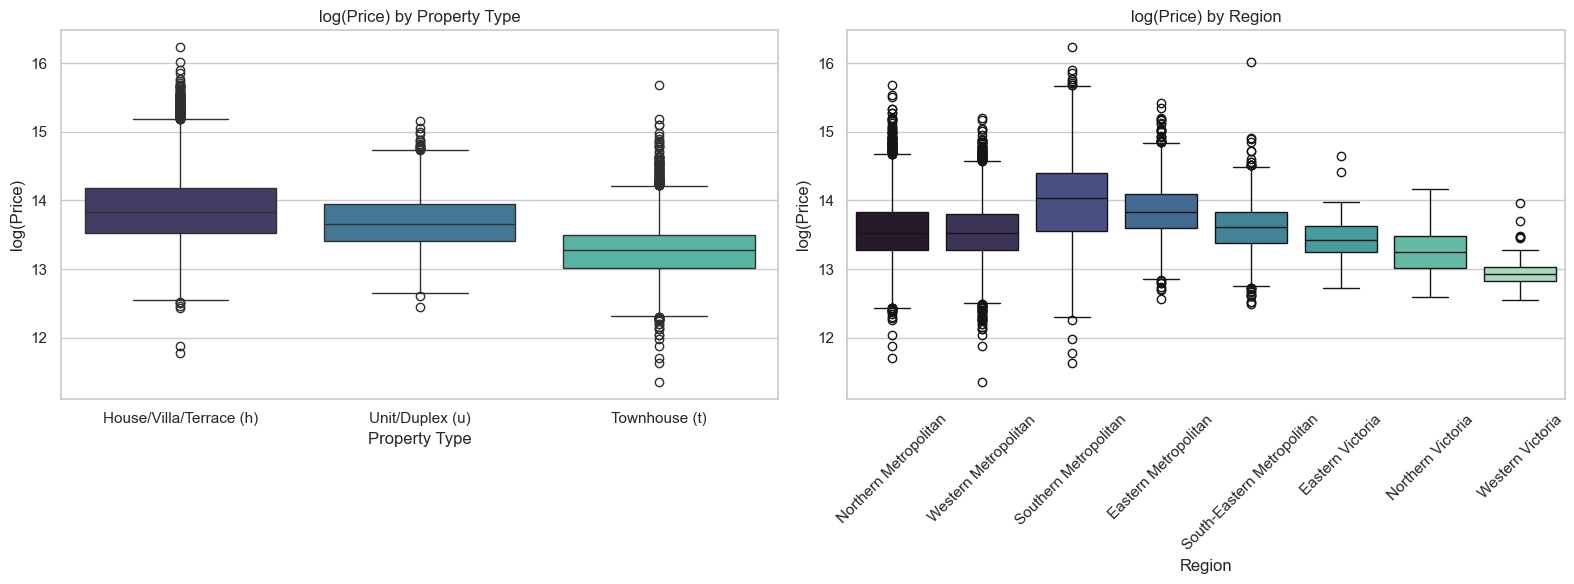

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Property Type
sns.boxplot(data=df, x='Type', y=np.log(df['Price']), 
            ax=axes[0], palette='mako')
axes[0].set_title('log(Price) by Property Type')
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('log(Price)')
axes[0].set_xticklabels(['House/Villa/Terrace (h)', 
                          'Unit/Duplex (u)', 
                          'Townhouse (t)'])

# Region
sns.boxplot(data=df, x='Regionname', y=np.log(df['Price']), 
            ax=axes[1], palette='mako')
axes[1].set_title('log(Price) by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('log(Price)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Train/Test Split

We split the data before any imputation or outlier handling to prevent 
data leakage — ensuring the test set remains completely unseen during 
the training process. We use an 80/20 split with a fixed random seed 
for reproducibility.

In [28]:
# Define features and target
features = ['Rooms', 'Distance', 'Bathroom', 'Car', 
            'BuildingArea', 'Landsize', 'YearBuilt', 
            'Type', 'Regionname']

target = 'Price'

# Split
X = df[features]
y = np.log(df[target])  # log transform the target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"Total:         {df.shape[0]} rows")

Training set:  21796 rows
Test set:      5450 rows
Total:         27246 rows


### Split Summary
- Training set: 21,796 rows (80%)
- Test set: 5,450 rows (20%)

`log(Price)` is applied to the target variable at this stage because:
1. The raw price distribution is heavily right-skewed, violating ordinary least squares (OLS) assumptions
2. Applying the transform here keeps the original `Price` column intact, 
   allowing us to convert predictions back to AUD for model evaluation

## 6. Handling Missing Data & Outliers

Now that the data is split, we can safely impute missing values without 
risk of data leakage. Our approach:
- Compute medians **only from the training set**
- Apply those same medians to both train and test sets
- Cap extreme outliers using the interquartile range (IQR) method
- All operations are fit on training data only

In [18]:
print("Missing values in training set:")
print(X_train.isnull().sum())
print("\nMissing values in test set:")
print(X_test.isnull().sum())

Missing values in training set:
Rooms               0
Distance            1
Bathroom         5139
Car              5445
BuildingArea    13224
Landsize         7417
YearBuilt       12077
Type                0
Regionname          3
dtype: int64

Missing values in test set:
Rooms              0
Distance           0
Bathroom        1308
Car             1379
BuildingArea    3367
Landsize        1848
YearBuilt       3086
Type               0
Regionname         0
dtype: int64


### 6.1 Feature Decision: Handling High-Missingness Columns

Three columns exceeded the safe imputation threshold:

| Column | Missingness | Decision |
|---|---|---|
| `BuildingArea` | 60% | **Dropped** — imputing 60% would flood the column with a single median value, weakening and distorting the predictor |
| `YearBuilt` | 55% | **Dropped** — same reasoning; over half the values would be artificial |
| `Landsize` | 34% | **Kept** — highest missingness among retained features, but most defensible |

Imputing over 50% of a column replaces genuine variation with a constant, 
creating artificial relationships and misleading coefficients. `Landsize` 
at 34% is a more acceptable tradeoff, and satisfies the transformation 
requirement via `log(Landsize)`.

In [19]:
# Drop high-missingness columns
X_train = X_train.drop(columns=['BuildingArea', 'YearBuilt'])
X_test = X_test.drop(columns=['BuildingArea', 'YearBuilt'])

# Drop rows with missing Regionname in training set (only 3)
missing_region = X_train['Regionname'].isnull()
X_train = X_train[~missing_region]
y_train = y_train[~missing_region]

# Numeric columns to impute
numeric_cols = ['Distance', 'Bathroom', 'Car', 'Landsize']

# Compute medians from TRAINING set only (leakage prevention)
train_medians = X_train[numeric_cols].median()
print("Training set medians:")
print(train_medians.round(2))

# Apply training medians to BOTH sets
X_train[numeric_cols] = X_train[numeric_cols].fillna(train_medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(train_medians)

# Verify
print("\nMissing values remaining — train:")
print(X_train.isnull().sum())
print("\nMissing values remaining — test:")
print(X_test.isnull().sum())

Training set medians:
Distance     10.5
Bathroom      1.0
Car           2.0
Landsize    515.0
dtype: float64

Missing values remaining — train:
Rooms         0
Distance      0
Bathroom      0
Car           0
Landsize      0
Type          0
Regionname    0
dtype: int64

Missing values remaining — test:
Rooms         0
Distance      0
Bathroom      0
Car           0
Landsize      0
Type          0
Regionname    0
dtype: int64


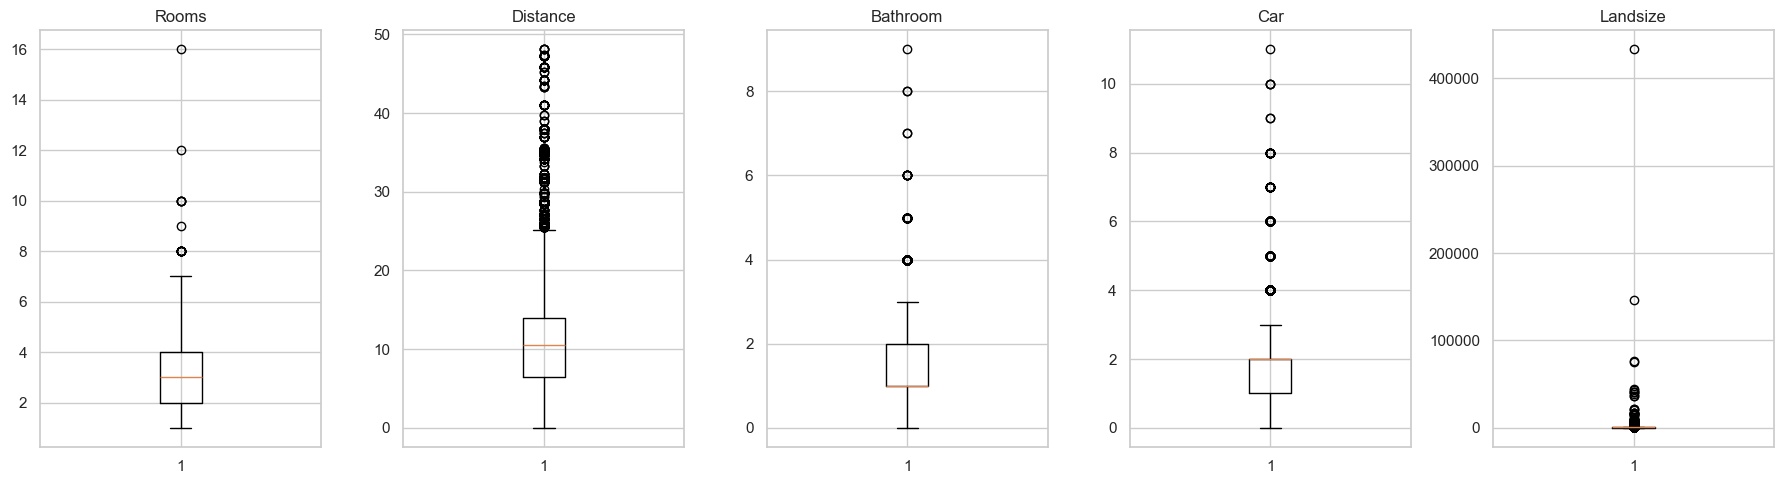

In [20]:
numeric_cols = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(X_train[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 6.2 Outlier Handling

We cap (winsorize) outliers rather than remove them — extreme values like 
very large land parcels are legitimate properties, not data errors, so we 
retain the rows but limit extreme values to the IQR-based boundaries.

Bounds are computed from the **training set only** and applied to both sets 
to prevent leakage. We cap `Landsize`, `Rooms`, `Bathroom`, and `Car`.

In [21]:
def get_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

cols_to_cap = ['Landsize', 'Rooms', 'Bathroom', 'Car']

for col in cols_to_cap:
    lower, upper = get_iqr_bounds(X_train[col])   # bounds from TRAIN only
    print(f"{col}: capping to [{lower:.1f}, {upper:.1f}]")
    # Apply same bounds to both sets
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

print("\nLandsize after capping — train:")
print(X_train['Landsize'].describe().round(1))

Landsize: capping to [-9.5, 954.5]
Rooms: capping to [-1.0, 7.0]
Bathroom: capping to [-0.5, 3.5]
Car: capping to [-0.5, 3.5]

Landsize after capping — train:
count    21793.0
mean       478.7
std        228.1
min          0.0
25%        352.0
50%        515.0
75%        593.0
max        954.5
Name: Landsize, dtype: float64


**Note:** `Distance` is deliberately not capped. Its high values represent 
genuine outer-suburb properties, not anomalies — and distance is a 
meaningful price driver we want to preserve in full.

## 7. Feature Engineering

We prepare features for modelling:
- One-hot encode the categorical variables (`Type`, `Regionname`)

In [22]:
print("Skew before log:", X_train['Landsize'].skew().round(2))
print("Skew after log:", np.log1p(X_train['Landsize']).skew().round(2))

Skew before log: -0.36
Skew after log: -2.9


**Note on transformations:** We tested a `log` transform on `Landsize` but 
it *increased* skew (from −0.36 to −2.9), because the column's many small/zero 
values get pulled into a long left tail. The transformation was therefore 
rejected. Our required transformation is `log(Price)` on the target variable, 
which corrected the target's heavy right skew (see Section 4.1).

### 7.1 One-Hot Encoding

We one-hot encode `Type` and `Regionname`, dropping the first category of 
each to serve as the baseline. The 
baseline categories become the reference point against which the other 
categories' coefficients are interpreted.

We align the test set columns to the training set to ensure both have 
identical features, even if a rare category is absent from one split.

In [23]:
# One-hot encode, dropping first category as baseline
X_train_enc = pd.get_dummies(X_train, columns=['Type', 'Regionname'], 
                              drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=['Type', 'Regionname'], 
                             drop_first=True)

# Align test columns to train (fill any missing dummy cols with 0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Convert boolean dummy columns to integers (statsmodels prefers numeric)
X_train_enc = X_train_enc.astype({col: int for col in X_train_enc.columns 
                                    if X_train_enc[col].dtype == bool})
X_test_enc = X_test_enc.astype({col: int for col in X_test_enc.columns 
                                  if X_test_enc[col].dtype == bool})

print("Encoded feature columns:")
print(X_train_enc.columns.tolist())
print(f"\nTrain shape: {X_train_enc.shape}")
print(f"Test shape:  {X_test_enc.shape}")

Encoded feature columns:
['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Type_t', 'Type_u', 'Regionname_Eastern Victoria', 'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria', 'Regionname_South-Eastern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan', 'Regionname_Western Victoria']

Train shape: (21793, 14)
Test shape:  (5450, 14)


## 8. Regression Model — Ordinary Least Squares

We fit an OLS linear regression using `statsmodels`, which provides detailed 
statistical output (coefficients, p-values, R², confidence intervals).

The model predicts `log(Price)` from our numeric and one-hot encoded 
categorical features. We add a constant term to represent the intercept (β₀).

In [24]:
# Add intercept term (the constant β₀)
X_train_sm = sm.add_constant(X_train_enc)
X_test_sm = sm.add_constant(X_test_enc)

# Fit OLS model on training data
model = sm.OLS(y_train, X_train_sm).fit()

# Show full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3341.
Date:                Mon, 06 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:58:12   Log-Likelihood:                -3999.1
No. Observations:               21793   AIC:                             8028.
Df Residuals:                   21778   BIC:                             8148.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

### 8.1 Model Summary & Interpretation

The OLS model explains **68.2%** of the variation in `log(Price)` 
(R² = 0.682, Adj. R² = 0.682). The F-statistic p-value (≈ 0.00) confirms 
the model is statistically significant overall.

**Statistical significance:** All predictors are significant (p < 0.05) 
*except* `Regionname_Northern Victoria` (p = 0.237), whose confidence 
interval crosses zero — the model cannot confidently distinguish its 
effect from the baseline region.

**Coefficient interpretation** (target is `log(Price)`, so effects are 
approximately multiplicative; exact effect = `exp(coef) − 1`):

| Variable | Coef | Interpretation |
|---|---|---|
| `Rooms` | +0.189 | Each extra room increases price by ~21% |
| `Distance` | −0.040 | Each km from CBD decreases price by ~3.9% |
| `Bathroom` | +0.080 | Each extra bathroom increases price by ~8% |
| `Type_u` | −0.509 | Units are ~40% cheaper than houses (baseline) |
| `Type_t` | −0.175 | Townhouses are ~16% cheaper than houses (baseline) |
| `Regionname_Southern Metropolitan` | +0.134 | ~14% more expensive than baseline region |
| `Regionname_Western Metropolitan` | −0.351 | ~30% cheaper than baseline region |

**Baselines:** houses (`Type`) and Eastern Metropolitan (`Regionname`).

**Caveat:** The condition number (9.5e+03) indicates multicollinearity — 
consistent with the moderate correlation between `Rooms` and `Bathroom` 
observed in EDA. Individual coefficients should be interpreted with 
some caution, though overall model fit is unaffected.

## 9. Model Evaluation

We now evaluate the model on the **unseen test set** to assess how well it 
generalises. We report:
- **R²** on the test set (compared to training R² to check for overfitting)
- **RMSE** and **MAE**, converted back to real AUD for interpretability

Since the model predicts `log(Price)`, predictions are exponentiated back 
to the dollar scale before computing error metrics.

In [27]:
# Predict on test set (predictions are in log scale)
y_pred_log = model.predict(X_test_sm)

# R² on the log scale (test set)
test_r2 = r2_score(y_test, y_pred_log)
print(f"Test R²: {test_r2:.3f}")
print(f"Train R²: {model.rsquared:.3f}")

# Convert both predictions and actuals back to AUD
y_pred_aud = np.exp(y_pred_log)
y_test_aud = np.exp(y_test)

# Error metrics in real dollars
rmse = np.sqrt(mean_squared_error(y_test_aud, y_pred_aud))
mae = mean_absolute_error(y_test_aud, y_pred_aud)

print(f"\nRMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")

Test R²: 0.674
Train R²: 0.682

RMSE: $421,433
MAE:  $248,738


### 9.1 Evaluation Summary

| Metric | Value | Interpretation |
|---|---|---|
| Train R² | 0.682 | Model explains 68.2% of variance in log(Price) on training data |
| Test R² | 0.674 | Explains 67.4% on unseen data — minimal gap confirms no overfitting |
| RMSE | $421,433 | Typical error, penalising large misses heavily |
| MAE | $248,738 | Average prediction error in absolute dollars |

**Interpretation:**

- The small gap between train R² (0.682) and test R² (0.674) shows the model 
  **generalises well** — it performs almost as well on unseen data as on the 
  data it was trained on, indicating no meaningful overfitting.

- MAE of ~$249k represents roughly **29% of the median house price** (~$870k). 
  This is a reasonable but not precise estimate — useful as a ballpark for a 
  buyer, but with meaningful uncertainty.

- RMSE (~$421k) is substantially larger than MAE (~$249k). Since RMSE weights 
  large errors more heavily, this gap indicates the model makes some **large 
  individual errors**, most likely on high-value properties — consistent with 
  the difficulty of predicting the upper price tail.

**Note:** Because predictions were made on the log scale and exponentiated 
back to dollars, a small downward bias is introduced (the exponential of the 
mean is not the mean of the exponentials). This does not materially affect 
the conclusions.

## 10. Conclusions

### Summary of Findings

We built an OLS regression model to estimate Melbourne house prices from 
property characteristics, using `log(Price)` as the target to correct for 
heavy right skew. The final model explains **67.4% of price variation on 
unseen data**, with a typical prediction error (MAE) of ~$249k.

### Which Variables Have the Most Predictive Power?

Based on coefficient magnitude and statistical significance:

1. **Property Type** — the strongest categorical driver. Units are ~40% 
   cheaper and townhouses ~16% cheaper than houses, reflecting land ownership.
2. **Rooms** — the strongest numeric driver. Each additional room adds ~21% 
   to price.
3. **Region** — location matters substantially. Western Metropolitan is ~30% 
   cheaper than the baseline (Eastern Metropolitan), while Southern 
   Metropolitan commands a premium.
4. **Distance from CBD** — each km further out reduces price by ~3.9%.
5. **Bathrooms** — each adds ~8%.

All predictors were statistically significant except Northern Victoria region.

### Practical Takeaway (for a Buyer)

For a buyer, the model confirms the biggest price levers are **property type, 
size (rooms), and location (region + distance from CBD)**. A house will cost 
substantially more than an equivalent unit; moving to an outer region or 
further from the CBD meaningfully lowers price. The model gives a reasonable 
ballpark (within ~29% on average) but should be treated as a guide, not a 
precise valuation.

### Limitations & Future Work

- **Dropped predictors:** `BuildingArea` and `YearBuilt` were strong candidates 
  but excluded due to >55% missing data. More sophisticated imputation (e.g. 
  KNN) could recover them and improve accuracy.
- **Location granularity:** `Suburb` holds far more location detail than 
  `Regionname`; incorporating it (with care for high cardinality) could help.
- **Model class:** Non-linear models (random forest, gradient boosting) 
  typically outperform OLS on this dataset, and interaction terms 
  (e.g. rooms × region) were not explored.
- **Multicollinearity:** The elevated condition number suggests some predictors 
  overlap (e.g. Rooms and Bathroom), so individual coefficients should be read 
  with mild caution.